In [1]:
# title import pkg
import warnings

warnings.filterwarnings("ignore")

import sys
import os


import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#plt.style.use("ggplot")
sns.set_theme(style="ticks")
sns.set_context("paper")
sns.color_palette("husl", 8)
#plt.style.use('grayscale')

import re
from tqdm import tqdm
from IPython.display import clear_output

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.linear_model import (
    LogisticRegressionCV,
    LassoCV,
    Lasso,
    LogisticRegression,
)


sys.path.append(os.path.abspath("../"))
from dmldid.model_rcs import DMLDiD_RCS

from dmldid.simdata_genrater import generate_simdata_ro, convert_rcs

In [ ]:
def generate_simdata_ro(
    true_att=3, _n=100, _dim=200, base_seed=1, xd_unobserved=False
) -> pd.DataFrame:
    np.random.seed(seed=base_seed)
    _gamma = [1 / (_i + 1) if _i < 5 else 0 for _i in range(_dim)]
    _beta = [-1 / (_i + 1) + 5 if _i < 5 else 0 for _i in range(_dim)]
    pre_beta = [2 / (_i + 1)  if _i < 5 else 0 for _i in range(_dim)]

    X = np.random.normal(0, 1, size=(_n, _dim))
    _df = pd.DataFrame(X)
    _df.columns = [f"x{i}" for i in range(_dim)]

    if xd_unobserved:
        _df["latent_xd"] = np.random.uniform(-1, 1, size=_n)
        for _i in range(5):
            _df[f"x{_i}"] += _df["latent_xd"] * (1 / (_i + 2))
        _gamma.append(-1.0)
        _beta.append(0)
        pre_beta.append(0)
        _X = _df.values
        log_odds = np.dot(_X, _gamma) + np.random.normal(0, 1, size=_n)
        ps = 1 / (1 + np.exp(-log_odds))
        del _df["latent_xd"]

        _df = _df.assign(
            D=np.random.binomial(1, ps),
            preY=np.dot(_X, pre_beta) + np.random.normal(0, 1, size=_n),
            pre_post_diff=np.dot(_X, _beta) + np.random.normal(0, 1, size=_n),
        )
    else:
        log_odds = np.dot(X, _gamma) + np.random.normal(0, 1, size=_n)
        ps = 1 / (1 + np.exp(-log_odds))
        _df = _df.assign(
            D=np.random.binomial(1, ps),
            preY=np.dot(X, pre_beta) + np.random.normal(0, 1, size=_n),
            pre_post_diff=np.dot(X, _beta) + np.random.normal(0, 1, size=_n),
        )
    _df["postY"] = _df.eval("preY + pre_post_diff")
    _df["postY"] = np.where(_df["D"] > 0, _df["postY"] + true_att, _df["postY"])

    del _df["pre_post_diff"]

    return _df


def convert_rcs(_df) -> pd.DataFrame:
    np.random.seed(seed=1)
    _df["y_flag"] = np.random.binomial(1, 0.5, size=len(_df))
    _df["Y"] = _df.apply(lambda x: x["postY"] if x["y_flag"] > 0 else x["preY"], axis=1)
    _df["T"] = _df.apply(lambda x: 1 if x["y_flag"] > 0 else 0, axis=1)
    return _df.drop(["preY", "postY", "y_flag"], axis=1)

In [2]:
df = convert_rcs(
    generate_simdata_ro(true_att=3, _n=500, _dim=100, base_seed=1, xd_unobserved=True)
)

df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x93,x94,x95,x96,x97,x98,x99,D,Y,T
0,1.472407,-0.713049,-0.604141,-1.133744,0.814761,-2.301539,1.744812,-0.761207,0.319039,-0.249370,...,-0.638730,0.423494,0.077340,-0.343854,0.043597,-0.620001,0.698032,0,-4.006645,0
1,-0.812332,0.981039,0.220890,0.447497,-1.216646,0.169382,0.740556,-0.953701,-0.266219,0.032615,...,1.111057,0.659050,-1.627438,0.602319,0.420282,0.810952,1.044442,0,-7.775538,1
2,-0.730676,0.604141,-0.727204,1.822959,-1.441884,-1.760689,-1.650721,-0.890556,-1.119115,1.956079,...,-0.680678,-0.084508,-0.297362,0.417302,0.784771,-0.955425,0.585910,1,-5.624429,0
3,2.117055,-1.436976,-0.804536,-0.860069,-0.262007,1.622849,0.013353,-0.694694,0.621804,-0.599805,...,0.477610,-1.021886,0.794528,-1.873161,0.920615,-0.035368,2.110605,1,-5.554239,0
4,-0.976193,0.296608,0.532403,1.365036,-0.312743,0.086464,-2.142467,-0.830169,0.451616,1.104174,...,0.451946,-1.579156,-0.828628,0.528880,-2.237087,-1.107713,-0.017718,0,-7.169597,0


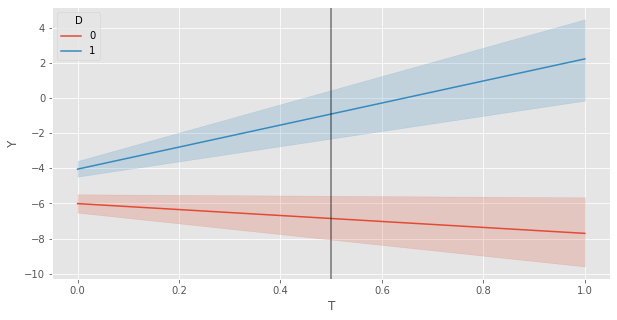

In [3]:
fig, ax = plt.subplots(1, 1, sharex="col", sharey="row", figsize=(10, 5))
sns.lineplot(x="T", y="Y", hue="D", data=df, ax=ax)
ax.axvline(x=0.5, alpha=0.5, color="black")
plt.show()

In [4]:
hat_lambda = df["T"].mean()

control_df = df.query("D < 1")
control_df["l2k_y"] = (control_df["T"] - hat_lambda) * control_df["Y"]

Text(0.5, 1.0, 'the regression(X -> l2k label) dones not make sense ')

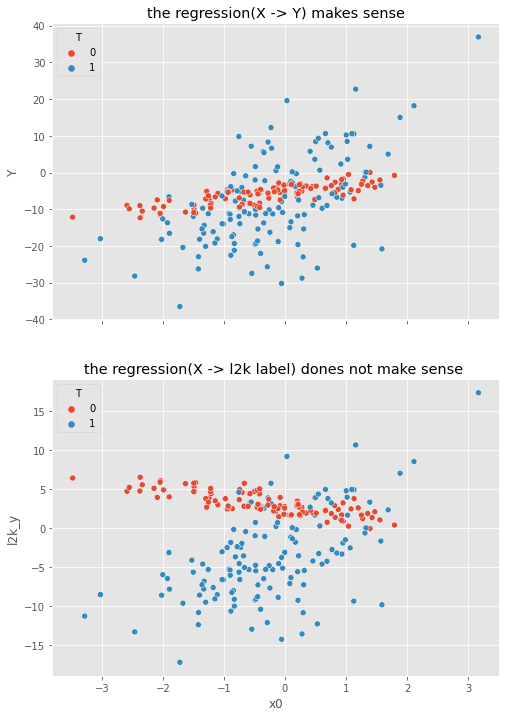

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(8, 12), sharex=True)

sns.scatterplot(x="x0", y="Y", hue="T", data=control_df, ax=axs[0])
axs[0].set_title("the regression(X -> Y) makes sense")


sns.scatterplot(x="x0", y="l2k_y", hue="T", data=control_df, ax=axs[1])
axs[1].set_title("the regression(X -> l2k label) dones not make sense ")

In [6]:
sim_cnt = 100
y_col = "Y"
d_col = "D"
t_col = "T"

In [7]:
linear_dml_no_separate = []
linear_dml_with_separate = []
lgbm_dml = []
abadie_semidid = []


for i in range(sim_cnt):
    df = convert_rcs(
        generate_simdata_ro(true_att=3, _n=500, _dim=100, base_seed=i, xd_unobserved=True)
    )
    X_cols = [col for col in df.columns if "x" in col]

    linear_dmldid = DMLDiD_RCS()
    linear_dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=True,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
        l2k_model_separate=False,
    )
    linear_dml_no_separate.append(linear_dmldid.att())

    linear_dmldid = DMLDiD_RCS()
    linear_dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=True,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
        l2k_model_separate=True,
    )
    linear_dml_with_separate.append(linear_dmldid.att())

    linear_dmldid = DMLDiD_RCS()
    linear_dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=False,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
    )
    abadie_semidid.append(linear_dmldid.att())

    lgbm_dmldid = DMLDiD_RCS(
        d_model=LGBMClassifier(random_state=0),
        l2k_model=LGBMRegressor(random_state=0),
    )

    lgbm_dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=True,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
        l2k_model_separate=False,
    )
    lgbm_dml.append(lgbm_dmldid.att())

    clear_output(wait=True)
    print(f"{i} linear_dml_no_separate : ", np.mean(linear_dml_no_separate))
    print(f"{i} linear_dml_with_separate : ", np.mean(linear_dml_with_separate))
    print(f"{i} abadie_semidid : ", np.mean(abadie_semidid))
    print(f"{i} lgbm_dml : ", np.mean(lgbm_dml))

99 linear_dml_no_separate :  6.2171219319963145
99 linear_dml_with_separate :  3.115351332163399
99 abadie_semidid :  6.604765867652821
99 lgbm_dml :  -3.397022036370499


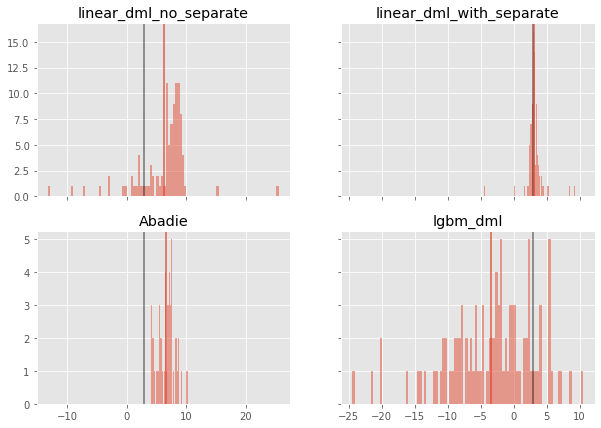

In [8]:
_label = [
    "linear_dml_no_separate",
    "linear_dml_with_separate",
    "Abadie",
    "lgbm_dml",
]
result_df = pd.DataFrame(
    {
        "linear_dml_no_separate": linear_dml_no_separate,
        "linear_dml_with_separate": linear_dml_with_separate,
        "abadie_semidid":abadie_semidid,
        "lgbm_dml_with_separate": lgbm_dml,
    }
)
fig, ax = plt.subplots(2, 2, sharex="col", sharey="row", figsize=(10, 7))
ax = ax.ravel()
for i, _col in enumerate(result_df.columns):
    ax[i].hist(result_df[_col], bins=100, alpha=0.5)
    # ax[i].set_xlim(0,5)
    ax[i].set_title(_label[i])
    ax[i].axvline(x=3, alpha=0.5, color="black")
    ax[i].axvline(x=result_df[_col].mean(), alpha=0.9)
plt.show()

In [9]:
# 確認
from dmldid.model_ro import DMLDiD_RO

In [10]:
def naive_did(
    df,
    y1_col,
    y0_col,
    d_col,
) -> np.float:
    _pivot = df.groupby(d_col)[[y0_col, y1_col]].mean()
    _pivot["diff"] = _pivot.diff(axis=1)[y1_col]
    return _pivot["diff"].diff().values[-1]

In [11]:
y1_col = "postY"
y0_col = "preY"
df_ro = generate_simdata_ro(
            _dim=100, _n=500, base_seed=i, xd_unobserved=True
        )

In [12]:
print("naive_did : ", naive_did(df_ro, y1_col, y0_col, d_col))

naive_did :  8.7528096123282


In [13]:
naive_did_list = []
linear_dml_list = []
lgbm_dml_list = []
abadie_semidid = []
sim_cnt=100

for i in range(sim_cnt):
    df =  generate_simdata_ro(
            _dim=100, _n=500, base_seed=i, xd_unobserved=True
        )
    X_cols = [col for col in df.columns if "x" in col]
    
    
    naive_did_list.append(
         naive_did(df, y1_col, y0_col, d_col)
    )
    linear_dmldid =DMLDiD_RO()
    linear_dmldid.fit(
        df,
        y1_col,
        y0_col,
        d_col,
        X_cols,
        dmldid=True,
        sim_cnt=1,
        base_random_seed=0,
    )
    linear_dml_list.append(linear_dmldid.att())

    linear_dmldid = DMLDiD_RO()
    linear_dmldid.fit(
        df,
        y1_col,
        y0_col,
        d_col,
        X_cols,
        dmldid=False,
        sim_cnt=1,
        base_random_seed=0,
    )
    abadie_semidid.append(linear_dmldid.att())

    
    lgbm_dmldid = DMLDiD_RO(
        d_model=LGBMClassifier(random_state=0),
        l2k_model=LGBMRegressor(random_state=0),
    )

    lgbm_dmldid.fit(
        df,
        y1_col,
        y0_col,
        d_col,
        X_cols,
        dmldid=True,
        sim_cnt=1,
        base_random_seed=0,
    )
    lgbm_dml_list.append(lgbm_dmldid.att())

    clear_output(wait=True)
    print(f"{i} linear_dml : ", np.mean(linear_dml_list))
    print(f"{i} abadie_semidid : ", np.mean(abadie_semidid))
    print(f"{i} lgbm_dml : ", np.mean(lgbm_dml_list))

99 linear_dml :  3.1002442988199586
99 abadie_semidid :  6.510757673034308
99 lgbm_dml :  2.6467219145476717


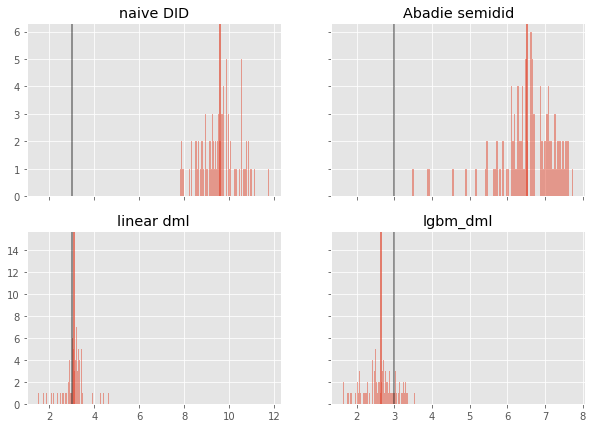

In [14]:
_label = [
    "naive DID",
    "Abadie semidid",
    "linear dml",
    "lgbm_dml",
]
result_df = pd.DataFrame(
    {
        "naive_did_list": naive_did_list,
        "abadie_semidid": abadie_semidid,
        "linear_dml":linear_dml_list,
        "lgbm_dml": lgbm_dml_list,
    }
)
fig, ax = plt.subplots(2, 2, sharex="col", sharey="row", figsize=(10, 7))
ax = ax.ravel()
for i, _col in enumerate(result_df.columns):
    ax[i].hist(result_df[_col], bins=100, alpha=0.5)
    # ax[i].set_xlim(0,5)
    ax[i].set_title(_label[i])
    ax[i].axvline(x=3, alpha=0.5, color="black")
    ax[i].axvline(x=result_df[_col].mean(), alpha=0.9)
plt.show()

In [15]:
print("以下テスト")

以下テスト


In [ ]:
df = convert_rcs(
    generate_simdata_ro(true_att=3, _n=500, _dim=100, base_seed=1, xd_unobserved=True)
)

df.head()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
import statsmodels.formula.api as smf
from contextlib import redirect_stdout
from scipy.stats import norm

class D2ML:
    """
    Doblue/Debiased Machine Learning
    """

    def __init__(
        self,
        data: pd.DataFrame,
        t_col: str,
        y_col: str,
        x_cols_for_t: list,
        x_cols_for_y: list,
        x_cols_for_cate: list,
        unit_id=None,
        t_model=LGBMClassifier(random_state=0),
        outcome_model=LGBMRegressor(random_state=0),
        cate_model=LGBMRegressor(random_state=0),
        n_bootstrap_samples=100,
    ):
        # params
        self._ate = None
        self._att = None
        self._bootstrap_ate = []
        self._bootstrap_att = []
        self.df_dml = None
        self.data = data
        self.t_col = t_col
        self.y_col = y_col
        self.x_cols_for_t = x_cols_for_t
        self.x_cols_for_y = x_cols_for_y
        self.x_cols_for_cate = x_cols_for_cate
        self.unit_id = unit_id
        self.n_bootstrap_samples = n_bootstrap_samples
        # model
        self.t_model = t_model
        self.outcome_model = outcome_model
        self.cate_model = cate_model
        self.ate_model_result = None
        self.explainer = None

    def fit_ate(
        self, eps=1e-3, cv=5, return_ate=False, bootstrap_data=pd.DataFrame([])
    ):
        if len(bootstrap_data) < 1:
            df_dml = self.data.copy()
        else:
            df_dml = bootstrap_data.copy()

        if df_dml[self.t_col].nunique() == 2:
            # t model for T residual
            df_dml = df_dml.assign(
                t_pred=np.clip(
                    cross_val_predict(
                        self.t_model,
                        df_dml[self.x_cols_for_t],
                        df_dml[self.t_col],
                        cv=cv,
                        method="predict_proba",
                    )[:, 1],
                    eps,
                    1 - eps,
                )
            )
            df_dml = df_dml.assign(
                t_res=df_dml[self.t_col] - df_dml["t_pred"],  # T residual
            )
        else:
            df_dml = df_dml.assign(
                t_res=df_dml[self.t_col]
                - cross_val_predict(
                    self.t_model, df_dml[self.x_cols_for_t], df_dml[self.t_col], cv=cv
                ),
            )

        # y model for Y residual
        df_dml = df_dml.assign(
            y_res=df_dml[self.y_col]
            - cross_val_predict(
                self.outcome_model, df_dml[self.x_cols_for_y], df_dml[self.y_col], cv=cv
            ),
        )

        if self.unit_id == None:
            final_model = smf.ols(formula="y_res ~ t_res", data=df_dml).fit()
        else:
            final_model = smf.ols(formula="y_res ~ t_res", data=df_dml).fit(
                cov_type="cluster", cov_kwds={"groups": df_dml[self.unit_id]}
            )

        if return_ate:
            return final_model.params["t_res"], df_dml
        else:
            self._ate = final_model.params["t_res"]
            df_dml["ate"] = self._ate
            self.ate_model_result = final_model
            self.df_dml = df_dml

    def sim_bootstrap(self, eps=1e-3, cv=5, result_return=False):
        self._bootstrap_ate = []
        self._bootstrap_att = []
        _n = len(self.data)
        for i in tqdm(range(self.n_bootstrap_samples)):
            _df_dml = self.data.sample(n=_n, replace=True, random_state=i).reset_index(
                drop=True
            )
            with redirect_stdout(open(os.devnull, "w")):
                _ate, _df_dml =self.fit_ate(
                        eps=eps, cv=cv, return_ate=True, bootstrap_data=_df_dml
                    )
            
            self._bootstrap_ate.append(_ate)

            _att = self.fit_nonlinear_cate(return_att=True, bootstrap_data=_df_dml)
            self._bootstrap_att.append(_att)

        self._att = np.mean(self._bootstrap_att)
        self._ate = np.mean(self._bootstrap_ate) # rewrite
        if result_return:
            return self._bootstrap_ate, self._bootstrap_att

    def stderr(self, effect_type="ate"):
        if len(self._bootstrap_ate) == 0:
            self.sim_bootstrap()
        if effect_type=="ate":
            return np.std(self._bootstrap_ate)
        else:
            return np.std(self._bootstrap_att)

    def summary(self, alpha=0.05, effect_type="ate"):
        assert effect_type in ["ate", "att"]
        if self._ate == None:
            self.fit_ate()

        stderr = self.stderr(effect_type= effect_type)

        if effect_type=="ate":
            _effect = self._ate
        else:
            _effect = self._att
        
        z_stat = (_effect - 0) / stderr
        p_value = norm.sf(np.abs(z_stat), loc=0, scale=1) * 2
        # confidence interval
        ci_lower = norm.ppf(alpha / 2, loc=_effect, scale=stderr)
        ci_higher = norm.ppf(1 - alpha / 2, loc=_effect, scale=stderr)
        return pd.DataFrame(
            {
                "effect": _effect,
                "standard_error": stderr,
                "z_stat": z_stat,
                "p_value": p_value,
                f"CI {alpha}": ci_lower,
                f"CI {1-alpha}": ci_higher,
            },
            index=["t"],
        )

    def fit_linear_cate(self, linear_cate_Xcols=None):
        if self._ate == None:
            self.fit_ate()

        if linear_cate_Xcols == None:
            linear_cate_Xcols = self.x_cols_for_cate

        formula = "y_res ~ t_res*("
        formula += "+".join(linear_cate_Xcols)
        formula += ")"

        if self.unit_id == None:
            cate_linear_model = smf.ols(formula, data=self.df_dml).fit()
        else:
            cate_linear_model = smf.ols(formula, data=self.df_dml).fit(
                cov_type="cluster", cov_kwds={"groups": self.df_dml[self.unit_id]}
            )
        print("Warning: This STANDARD ERROR is not accurate!")
        print(cate_linear_model.summary().tables[1])

        self.df_dml = self.df_dml.assign(
            linear_cate=cate_linear_model.predict(self.df_dml.assign(t_res=1))
            - cate_linear_model.predict(self.df_dml.assign(t_res=0)),
        )

    def fit_nonlinear_cate(self, cap_att=True ,return_att=False,bootstrap_data=pd.DataFrame([])):
        if self._ate == None:
            self.fit_ate()

        if len(bootstrap_data) == 0:
            df_dml = self.df_dml.copy()
        else:
            df_dml = bootstrap_data.copy()

        model_weight = df_dml["t_res"] ** 2  # 残差の二乗
        cate_model_y = df_dml["y_res"] / df_dml["t_res"]  # 新しい教師ラベル

        self.cate_model.fit(
            X=df_dml[self.x_cols_for_cate], y=cate_model_y, sample_weight=model_weight
        )

        df_dml = df_dml.assign(
            non_linear_cate=self.cate_model.predict(df_dml[self.x_cols_for_cate])
        )
        # df_dml = df_dml.assign(
        #     non_linear_cate= cross_val_predict(
        #         self.cate_model, df_dml[self.x_cols_for_cate], cate_model_y, cv=cv, fit_params={"sample_weight":model_weight}
        #         )
        #     )
        if cap_att:
            q_low = df_dml["non_linear_cate"].quantile(0.01)
            q_hi  = df_dml["non_linear_cate"].quantile(0.99)
            df_dml["non_linear_cate"]=df_dml["non_linear_cate"].clip(lower=q_low , upper=q_hi)

        
        if return_att:
            return df_dml.query(f"{self.t_col} > 0")["non_linear_cate"].mean()
        else:
            self.df_dml = df_dml

class DynamicD2ML:
    """
    Dynamic Doblue/Debiased Machine Learning
    """

    def __init__(
        self,
        data: pd.DataFrame,
        time_col :str,
        t_col: str,
        y_col: str,
        x_cols_for_t: list,
        x_cols_for_y: list,
        x_cols_for_cate: list,
        t_model=LGBMClassifier(random_state=0),
        outcome_model=LGBMRegressor(random_state=0),
        cate_model=LGBMRegressor(random_state=0),
        n_bootstrap_samples=100,
    ):
        # params
        self.time_ate = {}
        self.time_att = {}
        self._bootstrap_ate = []
        self._bootstrap_att = []
        self.df_dml = None
        self.data = data
        self.time_col = time_col
        self.t_col = t_col
        self.y_col = y_col
        self.x_cols_for_t = x_cols_for_t
        self.x_cols_for_y = x_cols_for_y
        self.x_cols_for_cate = x_cols_for_cate
        self.n_bootstrap_samples = n_bootstrap_samples
        # model
        self.t_model = t_model
        self.outcome_model = outcome_model
        self.cate_model = cate_model
        self.ate_model_result = None
    
    def fit(
        self, eps=1e-3, cap_att=True, bootstrap_data=pd.DataFrame([])
    ):
        if len(bootstrap_data) < 1:
            df_dml = self.data.copy()
        else:
            df_dml = bootstrap_data.copy()

        time_list = list(df_dml[self.time_col].unique()) 
        time_list.sort()

        self.time_ate = {}
        self.time_att = {}
        for i, _time in enumerate(time_list):
            _df_dml =df_dml.query(f"{self.time_col} == @_time")
            if _df_dml[self.t_col].sum() < 10:
                self.time_ate[_time] = None
                self.time_att[_time] = None
                continue

            split_dfs = train_test_split(_df_dml, test_size=0.5, random_state=i, stratify=_df_dml[self.t_col])
            res_dfs = []
            for f in range(2):
                s = 1 if f == 0 else 0
                t_model = clone(self.t_model)
                outcome_model = clone(self.outcome_model)
                t_model.fit(split_dfs[f][self.x_cols_for_t], split_dfs[f][self.t_col])
                outcome_model.fit(split_dfs[f][self.x_cols_for_y], split_dfs[f][self.y_col])

                res_dfs.append(
                    split_dfs[s].assign(
                        t_res = split_dfs[s][self.t_col] - np.clip(t_model.predict_proba(split_dfs[s][self.x_cols_for_t])[:,1], eps, 1 - eps),
                        y_res = split_dfs[s][self.y_col] - outcome_model.predict(split_dfs[s][self.x_cols_for_y])
                    )
                )
            res_df = pd.concat(res_dfs)

            final_model = smf.ols(formula="y_res ~ t_res", data=res_df).fit()
            self.time_ate[_time] = final_model.params["t_res"]

            # CATE
            model_weight = res_df["t_res"] ** 2  # 残差の二乗
            cate_model_y = res_df["y_res"] / res_df["t_res"]  # 新しい教師ラベル
            cate_model = clone(self.cate_model)

            cate_model.fit(
                X=res_df[self.x_cols_for_cate], y=cate_model_y, sample_weight=model_weight
            )

            res_df = res_df.assign(
                non_linear_cate=cate_model.predict(res_df[self.x_cols_for_cate])
            )
       
            if cap_att:
                q_low = res_df["non_linear_cate"].quantile(0.01)
                q_hi  = res_df["non_linear_cate"].quantile(0.99)
                res_df["non_linear_cate"]=res_df["non_linear_cate"].clip(lower=q_low , upper=q_hi)
            
            self.time_att[_time] = res_df.query(f"{self.t_col} > 0")["non_linear_cate"].mean()
    
    def df_time_ate(self):
        return pd.DataFrame(self.time_ate, index=["ate"]).T

    def df_time_att(self):
        return pd.DataFrame(self.time_att, index=["ate"]).T

    def sim_bootstrap(self, eps=1e-3, result_return=False):
        self._bootstrap_ate = []
        self._bootstrap_att = []
        _n = len(self.data)
        for i in tqdm(range(self.n_bootstrap_samples)):
            _df_dml = self.data.sample(n=_n, replace=True, random_state=i).reset_index(
                drop=True
            )
            with redirect_stdout(open(os.devnull, "w")):
                self.fit(
                        eps=eps, bootstrap_data=_df_dml
                    )
            
            self._bootstrap_ate.append(self.df_time_ate())
            self._bootstrap_att.append(self.df_time_att())

        _bootstrap_ate = pd.concat(self._bootstrap_ate, axis=1)
        _bootstrap_att = pd.concat(self._bootstrap_att, axis=1)
 
        if result_return:
            return _bootstrap_ate, _bootstrap_att

    def predict(self, alpha=0.05, effect_type="both"):
        if len(self._bootstrap_ate) < 2:
            self.sim_bootstrap()
        
        df_ate = pd.DataFrame( {"ate" : pd.concat(self._bootstrap_ate, axis=1).mean(axis=1)})
        df_ate["std"] = pd.concat(self._bootstrap_ate, axis=1).std(axis=1)
        df_ate = df_ate.assign(
            ci_lower = norm.ppf(alpha / 2, loc=df_ate["ate"], scale=df_ate["std"]),
            ci_higher = norm.ppf(1 - alpha / 2, loc=df_ate["ate"], scale=df_ate["std"]) 
        )
        df_att = pd.DataFrame( {"att" : pd.concat(self._bootstrap_att, axis=1).mean(axis=1)})
        df_att["std"] = pd.concat(self._bootstrap_att, axis=1).std(axis=1)
        df_att = df_att.assign(
            ci_lower = norm.ppf(alpha / 2, loc=df_att["att"], scale=df_att["std"]),
            ci_higher = norm.ppf(1 - alpha / 2, loc=df_att["att"], scale=df_att["std"]) 
        )

        if effect_type=="both":
            return df_ate, df_att
        elif effect_type=="ate":
            return df_ate
        elif effect_type=="att":
            return df_att
        else:
            pass
    
    def plot(self, alpha=0.05, effect_type="ate"):
        assert effect_type in ["ate", "att"]
        _df = self.predict(effect_type=effect_type)

        ax = _df[effect_type].plot(
            label=effect_type, figsize=(12, 6)
        )
        ax.grid(color= (0.1, 0.1, 0.1), linestyle='--', linewidth=1, alpha=0.5)
        ax.fill_between(
            _df.index,
            _df["ci_lower"],
            _df["ci_higher"],
            alpha=0.25,
        )
        ax.axhline(
            y=0,
            color="black",
            linestyle="--",
        )
        plt.autoscale(enable=True, axis="x", tight=True)
        plt.ylabel(effect_type)
        sns.despine()

In [ ]:
X_cols = [col for col in df.columns if "x" in col]
X_cols_y = X_cols + ["T"]

In [ ]:
dml = D2ML(
    data=df,
    t_col="D",
    y_col="Y",
    x_cols_for_t=X_cols,
    x_cols_for_y=X_cols_y,
    x_cols_for_cate=X_cols,
    t_model=LGBMClassifier(random_state=0),
    outcome_model=LGBMRegressor(random_state=0),
    cate_model=LGBMRegressor(random_state=0),
    n_bootstrap_samples=100
)

In [ ]:
dml.summary(effect_type="att")

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

sns.kdeplot(dml._bootstrap_att,shade=True, color='red', ax=ax)
ax.set_title(
    f"bootstrap simulation for ATT: point estimate={dml._att:.4f},  $\sigma$={dml.stderr(effect_type='att'):.4f}"
)
ax.set_xlabel("tau")
ax.set_ylabel("freq")
ax.axvline(x=dml._att, color = "black",  linestyle='--', alpha=0.5)
fig.show()
